# Chargement des données

a la base, fichier train test. Creation de mon propre ensemble a partir du train ( split du train en train test). On n'utilise plus le test²

In [1]:
# Cellules pour détecter et charger un fichier CSV, inspecter les colonnes et faire un pré-traitement minimal.

import os
import glob
import pandas as pd
import tensorflow as tf
from IPython.display import display

In [2]:
base = r"c:\Users\yohan\OneDrive\Bureau\MY NBAI\02_NLP_Toxic_Comment_Detection"
path = r"data\train.csv"
# Lecture robuste (saute les lignes problématiques)
df = pd.read_csv(path, encoding="utf-8", on_bad_lines="skip")
display(df.head(10))

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0
5,00025465d4725e87,"""\n\nCongratulations from me as well, use the ...",0,0,0,0,0,0
6,0002bcb3da6cb337,COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK,1,1,1,0,1,0
7,00031b1e95af7921,Your vandalism to the Matt Shirvington article...,0,0,0,0,0,0
8,00037261f536c51d,Sorry if the word 'nonsense' was offensive to ...,0,0,0,0,0,0
9,00040093b2687caa,alignment on this subject and which are contra...,0,0,0,0,0,0


In [3]:
print("Data set:", df.shape)
print("Colonnes :", df.columns.tolist())
print("\nTypes :")
print(df.dtypes)
print("\nValeurs manquantes par colonne :")
print(df.isna().sum())

Data set: (159571, 8)
Colonnes : ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

Types :
id               object
comment_text     object
toxic             int64
severe_toxic      int64
obscene           int64
threat            int64
insult            int64
identity_hate     int64
dtype: object

Valeurs manquantes par colonne :
id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64


In [4]:
labels_columns = df.columns.tolist()[2:]
print("\nColonnes de labels :", labels_columns)


Colonnes de labels : ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']


In [5]:
label_counts = df[labels_columns].sum()
print("\nNombre de commentaires par label :\n",label_counts)


Nombre de commentaires par label :
 toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64


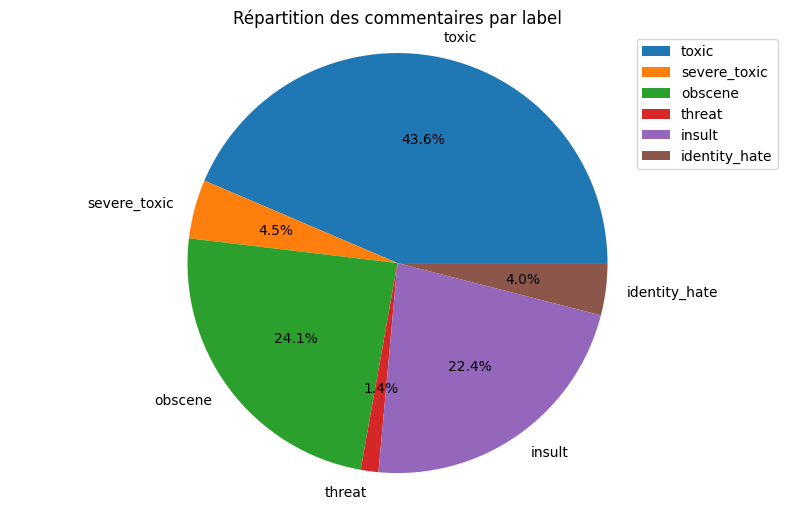

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.pie(label_counts.values, labels=labels_columns, autopct='%1.1f%%')
plt.title('Répartition des commentaires par label')
plt.axis('equal')  # Set the aspect ratio equal so that the pie is a circle
plt.legend(labels_columns, loc='upper right')  # Add a legend to the chart

plt.show()


In [7]:
# Certains labels sont trop peu représentés, on peut envisager de les regrouper
# par exemple en un seul label "toxic" + "severe_toxic".
# de meme avec "threat", "insult"

In [8]:
# Créez une nouvelle colonne "toxic" qui regroupe les labels "toxic" et "severe_toxic"
df['toxic_severe'] = df[['toxic', 'severe_toxic']].max(axis=1)


# Supprimez les colonnes "toxic" et "severe_toxic"
df = df.drop(['toxic', 'severe_toxic'], axis=1)


In [9]:
display(df.tail(10))

,id,comment_text,obscene,threat,insult,identity_hate,toxic_severe
159561,ffd2e85b07b3c7e4,"""\nNo he did not, read it again (I would have ...",0,0,0,0,0
159562,ffd72e9766c09c97,"""\n Auto guides and the motoring press are not...",0,0,0,0,0
159563,ffe029a7c79dc7fe,"""\nplease identify what part of BLP applies be...",0,0,0,0,0
159564,ffe897e7f7182c90,Catalan independentism is the social movement ...,0,0,0,0,0
159565,ffe8b9316245be30,The numbers in parentheses are the additional ...,0,0,0,0,0
159566,ffe987279560d7ff,""":::::And for the second time of asking, when ...",0,0,0,0,0
159567,ffea4adeee384e90,You should be ashamed of yourself \n\nThat is ...,0,0,0,0,0
159568,ffee36eab5c267c9,"Spitzer \n\nUmm, theres no actual article for ...",0,0,0,0,0
159569,fff125370e4aaaf3,And it looks like it was actually you who put ...,0,0,0,0,0
159570,fff46fc426af1f9a,"""\nAnd ... I really don't think you understand...",0,0,0,0,0


In [10]:
labels_columns = df.columns.tolist()[2:]
label_counts = df[labels_columns].sum()
print("\nNouveaux nombres de commentaires par label :\n",label_counts)


Nouveaux nombres de commentaires par label :
 obscene           8449
threat             478
insult            7877
identity_hate     1405
toxic_severe     15294
dtype: int64


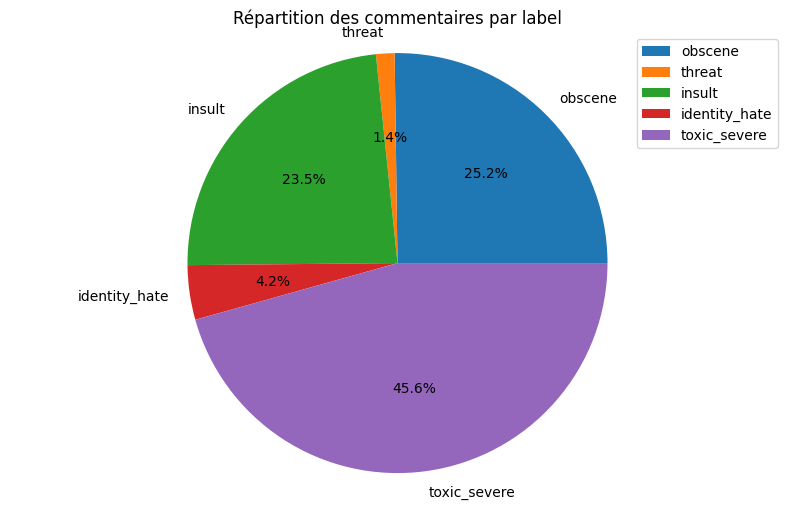

In [11]:
plt.figure(figsize=(10,6))
plt.pie(label_counts.values, labels=labels_columns, autopct='%1.1f%%')
plt.title('Répartition des commentaires par label')
plt.axis('equal')  # Set the aspect ratio equal so that the pie is a circle
plt.legend(labels_columns, loc='upper right')  # Add a legend to the chart

plt.show()

In [12]:
df.iloc[6]['comment_text']

'COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK'

In [13]:
df[df.columns[2:]].iloc[6]

obscene          1
threat           0
insult           1
identity_hate    0
toxic_severe     1
Name: 6, dtype: int64

# Preprocessing
    - Standardize each example (usually lowercasing + punctuation stripping)
    - Split each example into substrings (usually words)
    - Recombine substrings into tokens (usually ngrams)
    - Index tokens (associate a unique int value with each token)
    - Transform each example using this index, either into a vector of ints or a dense float vector

In [14]:
from keras.layers import TextVectorization

In [15]:
X = df['comment_text']
X

0         Explanation\nWhy the edits made under my usern...
1         D'aww! He matches this background colour I'm s...
2         Hey man, I'm really not trying to edit war. It...
3         "\nMore\nI can't make any real suggestions on ...
4         You, sir, are my hero. Any chance you remember...
                                ...                        
159566    ":::::And for the second time of asking, when ...
159567    You should be ashamed of yourself \n\nThat is ...
159568    Spitzer \n\nUmm, theres no actual article for ...
159569    And it looks like it was actually you who put ...
159570    "\nAnd ... I really don't think you understand...
Name: comment_text, Length: 159571, dtype: object

In [16]:
y= df[df.columns[2:]].values
y 

array([[0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0],
       ...,
       [0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0]], shape=(159571, 5))

In [17]:
MAX_WORDS = 200000 # nombre max de mots à prendre en compte

In [ ]:
# Avant Tokenization, on va faire la lemmatisation avec spacy
import spacy
import re

# Charger le modèle spaCy
nlp = spacy.load("en_core_web_sm")

# Prétraitement complet
def preprocess_text(comment):
    """
    Fonction pour nettoyer un texte en anglais :
    - Remove stopwords
    - Lemmatization
    """
    
    # Créer un doc spaCy
    doc = nlp(comment)
    
    # Construire la liste de tokens propres
    cleaned_tokens = [
        token.lemma_.lower()         # lemmatisation + lowercase
        for token in doc
        if not token.is_stop           # retirer stopwords
        and token.is_alpha             # garder que les mots alphabétiques
    ]
    
    # Retourner texte nettoyé
    return " ".join(cleaned_tokens)

print(X[6])
print(preprocess_text(X[6]))


COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK
cocksucker pis work


In [19]:
vectorizer = TextVectorization(max_tokens=MAX_WORDS, 
                               output_mode='int', 
                               output_sequence_length=1800)

In [22]:
X =X.apply(preprocess_text)

In [23]:
X[0]

'explanation edit username hardcore metallica fan revert vandalism closure gas vote new york dolls fac remove template talk page retire'

In [24]:
type(X)

pandas.core.series.Series

In [25]:
vectorizer.adapt(X.values) # X.values pour avoir un tableau numpy


In [26]:
# exemple de transformation
vectorizer('Hello world! This is a test comment.')[:7]# affiche les 7 premiers tokens

<tf.Tensor: shape=(7,), dtype=int64, numpy=array([   168,    124,      1, 116554,      1,    273,     29])>

In [27]:
vectorizer.get_vocabulary()[:10]  # affiche les 10 premiers mots du vocabulaire

['',
 '[UNK]',
 np.str_('article'),
 np.str_('page'),
 np.str_('wikipedia'),
 np.str_('talk'),
 np.str_('edit'),
 np.str_('like'),
 np.str_('think'),
 np.str_('know')]

In [28]:
vectorized_text = vectorizer(X.values)
vectorized_text

<tf.Tensor: shape=(159571, 1800), dtype=int64, numpy=
array([[  386,     6,   423, ...,     0,     0,     0],
       [  772,   473,  2085, ...,     0,     0,     0],
       [  258,   173,    41, ...,     0,     0,     0],
       ...,
       [22846,  5356,   373, ...,     0,     0,     0],
       [   27,     7,   101, ...,     0,     0,     0],
       [    8,   111,    55, ...,     0,     0,     0]],
      shape=(159571, 1800))>

### 1ere version non opti

In [ ]:
# dataset = tf.data.Dataset.from_tensor_slices((vectorized_text, y))
# dataset = dataset.cache() # pour garder en mémoire après la première époque
# dataset = dataset.shuffle(160000) # mélanger les données
# dataset = dataset.batch(128) # taille de batch de 128
# dataset = dataset.prefetch(8) # prefetch pour optimiser le pipeline

In [ ]:
# batch_X,batch_y = dataset.as_numpy_iterator().next() # obtenir un batch d'exemples
# batch_X.shape, batch_y.shape # afficher les dimensions des tenseurs X et y du batch

((128, 1800), (128, 5))

Train, val and test dataset creation

In [ ]:
# train = dataset.take(int(0.7 * len(dataset))) # 70% pour l'entrainement
# val = dataset.skip(int(0.7 * len(dataset))).take(int(0.2 * len(dataset))) # 20% pour la validation
# test = dataset.skip(int(0.9 * len(dataset))).take(int(0.1 * len(dataset))) # 10% pour le test

In [ ]:
# len(train), len(val), len(test)

(872, 249, 124)

In [ ]:
# train_generator = train.as_numpy_iterator()

In [ ]:
# train_generator.next()

(array([[    43,     32,    484, ...,      0,      0,      0],
        [   423, 103789,     18, ...,      0,      0,      0],
        [    90,    398,   1195, ...,      0,      0,      0],
        ...,
        [   348,     15,    813, ...,      0,      0,      0],
        [  1282,    183,   1909, ...,      0,      0,      0],
        [ 37123,    931,   1385, ...,      0,      0,      0]],
       shape=(128, 1800)),
 array([[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [1, 0, 1, 0, 1],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
      

### Version OPTI ( test )

In [51]:

BATCH_SIZE = 256
DATASET_SIZE = len(vectorized_text)  # 160000

# 1️ Dataset brut
dataset = tf.data.Dataset.from_tensor_slices((vectorized_text, y))

# 2 Shuffle AVANT split
dataset = dataset.shuffle(
    buffer_size=DATASET_SIZE,
    reshuffle_each_iteration=True
)

# 3️ Split PROPRE (avant batch)
train_size = int(0.7 * DATASET_SIZE)
val_size = int(0.2 * DATASET_SIZE)

train_ds = dataset.take(train_size)
val_ds = dataset.skip(train_size).take(val_size)
test_ds = dataset.skip(train_size + val_size)

# 4️ Batch + prefetch
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


# Deep Learning model building

In [52]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM,Bidirectional, Dropout, Dense, Embedding, Input, Conv1D, GlobalMaxPooling1D


In [53]:
MAX_LEN = 200 # 1800  = longueur des séquences après vectorization, pour l'entrainement 
# réduction de la taille des séquences possible pour accélérer l'entrainement
# toxicité des commentaires est souvent concentrée au début du texte

Version bidirectionnelle

In [54]:
model = Sequential()
model.add(Input(shape=(MAX_LEN,))) # couche d'entrée avec la taille des séquences
model.add(Embedding(MAX_WORDS + 1, 32)) # couche d'embedding

model.add(Bidirectional(LSTM(32, activation='tanh'))) # couche LSTM bidirectionnelle, important pour capturer le contexte des deux côtés

# couches Denses entierement connectées : features extraites
model.add(Dense(128, activation='relu'))
model.add(Dense(256, activation='relu')) 
model.add(Dense(128, activation='relu')) 

model.add(Dense(5, activation='sigmoid')) # couche de sortie pour 3 labels

Version CNN si trop long

In [55]:
# model = Sequential()
# model.add(Input(shape=(1000,))) # couche d'entrée avec la taille des séquences
# model.add(Embedding(MAX_WORDS + 1, 64)) # couche d'embedding

# model.add(Conv1D(128, kernel_size=5, activation="relu")) # couche convolutionnelle 1D
# model.add(GlobalMaxPooling1D())    # couche de pooling global

# model.add(Dense(256, activation="relu")) # couche dense entièrement connectée
# model.add(Dropout(0.5)) # couche de dropout pour régularisation
# model.add(Dense(5, activation="sigmoid")) # couche de sortie pour 5 labels



In [56]:
model.compile(loss='binary_crossentropy', optimizer='adam')


In [57]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 200, 32)        │     6,400,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 64)             │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,491,557 (24.76 MB)

 Trainable params: 6,491,557 (24.76 MB)

 Non-trainable params: 0 (0.00 B)

In [58]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=[early_stop]
)


Epoch 1/5
437/437 ━━━━━━━━━━━━━━━━━━━━ 4611s 11s/step - loss: 0.0990 - val_loss: 0.0551
Epoch 2/5
437/437 ━━━━━━━━━━━━━━━━━━━━ 10226s 23s/step - loss: 0.0526 - val_loss: 0.0471
Epoch 3/5
437/437 ━━━━━━━━━━━━━━━━━━━━ 42215s 97s/step - loss: 0.0464 - val_loss: 0.0411
Epoch 4/5
437/437 ━━━━━━━━━━━━━━━━━━━━ 5412s 12s/step - loss: 0.0421 - val_loss: 0.0392
Epoch 5/5
437/437 ━━━━━━━━━━━━━━━━━━━━ 14587s 33s/step - loss: 0.0388 - val_loss: 0.0360


In [59]:
from matplotlib import pyplot as plt

In [60]:
plt.figure(figsize=(12,6))
pd.DataFrame(history.history).plot()
plt.show()

NameError: name 'history' is not defined

<Figure size 1200x600 with 0 Axes>

Prédiction et test du modèle

In [61]:
input_text = vectorizer('this is bullshit, I hate it and the plot is boring.')

In [62]:
import numpy as np

In [63]:
model.predict(np.expand_dims(input_text,0)) # prédire sur un seul exemple

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 879ms/step


array([[0.7401524 , 0.0913    , 0.71546274, 0.2218132 , 0.9539931 ]],
      dtype=float32)

In [64]:
df.columns[2:].to_list()

['obscene', 'threat', 'insult', 'identity_hate', 'toxic_severe']

In [65]:
batch_X,batch_y = test_ds.as_numpy_iterator().next()

In [66]:
batch_y

array([[0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0],
       ...,
       [0, 0, 0, 0, 0],
       [0, 0, 0, 0, 1],
       [0, 0, 0, 0, 0]], shape=(256, 5))

In [67]:
tests_pred = (model.predict(batch_X) > 0.5).astype("int32")
tests_pred

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 182ms/step


array([[0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0],
       ...,
       [0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0]], shape=(256, 5), dtype=int32)

# Evaluation du modele

In [68]:
from tensorflow.keras.metrics import Precision, Recall, CategoricalAccuracy

In [79]:
pre = Precision()
re = Recall() 
acc= CategoricalAccuracy() 

In [ ]:
for batch in test_ds.as_numpy_iterator():
    X_true, y_true = batch
    #y_pred = model.predict(X_true)
    y_pred =(model.predict(X_true) > 0.5).astype("int32")

    y_pred = y_pred.flatten() # aplatir les prédictions pour correspondre à y_batch
    y_true = y_true.flatten() # aplatir y_batch

    print(y_true,y_pred)
    
    pre.update_state(y_true, y_pred)
    re.update_state(y_true, y_pred)
    acc.update_state(y_true, y_pred)

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 213ms/step
[0 0 0 ... 0 0 0] [4.6495905e-05 2.1446809e-05 3.4677709e-05 ... 6.9176222e-06 7.4059074e-07
 7.8417557e-05]
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 201ms/step
[0 0 0 ... 0 0 0] [2.9018223e-03 1.3672881e-03 3.4210077e-03 ... 6.6083635e-06 7.0526949e-07
 6.7817702e-05]
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 201ms/step
[0 0 0 ... 0 0 0] [1.85779863e-05 8.89263174e-06 1.23622585e-05 ... 1.55154921e-05
 1.86079353e-06 1.85795318e-04]
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 192ms/step
[0 0 0 ... 1 1 1] [4.0161193e-04 1.6222500e-04 3.3743097e-04 ... 9.0759414e-01 3.8393870e-01
 9.9543828e-01]
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 188ms/step
[0 0 0 ... 0 0 0] [1.8857312e-04 8.1743441e-05 1.5304187e-04 ... 8.2121516e-04 1.4728408e-04
 4.3864716e-03]
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 193ms/step
[0 0 0 ... 0 0 0] [1.5969466e-05 8.2798670e-06 1.0943632e-05 ... 1.3214327e-05 1.4858682e-06
 1.4927440e-04]
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 217ms/step
[0 0 0 ... 0 0 0] [3.9300139e-04 1.5284134e-04 3.2717703e-04 ... 5.

In [81]:
print(f'Precision: {pre.result().numpy():.4f}')
print(f'Recall: {re.result().numpy():.4f}')
print(f'Accuracy: {acc.result().numpy():.4f}')

Precision: 0.8234
Recall: 0.8414
Accuracy: 0.0000


# Deep Learning App avec Gradio

In [ ]:
import gradio as gr

In [ ]:
model.save("toxic_comment_model.keras")

In [ ]:
model = tf.keras.models.load_model("toxic_comment_model.keras")

In [ ]:
comment = vectorizer("Fuck you, I hate this movie and it is boring. I am coming to hurt you")

In [ ]:
res = model.predict(np.expand_dims(comment,0))
res

In [ ]:
labels = df.columns[2:].to_list()
labels

In [ ]:
def score_comment(comment):
    vectorized_comment = vectorizer([comment])
    res = model.predict(vectorized_comment)

    preds = []
    
    for index, col in enumerate(df.columns[2:]):
        if res[0][index]>0.5:
            preds.append(col)
    if len(preds)==0:
        text = 'Good Comment'
    else:
        text = ' Your comment is '
    for val in preds: 
        text += '{}, '.format(val)
    
    text +='!'
    return text

In [ ]:
score_comment('Fuck you')

In [ ]:
interface = gr.Interface(fn=score_comment,
                         inputs=gr.Textbox(lines=2, placeholder='Laisser un commentaire'),
                         outputs='text')

In [ ]:
interface.launch(share=True)